In [1]:
path = r"./dataset"
cat = ["no", "yes"]

In [2]:
import os

for i in cat:
    folders = os.path.join(path, i)
    print(folders)

./dataset\no
./dataset\yes


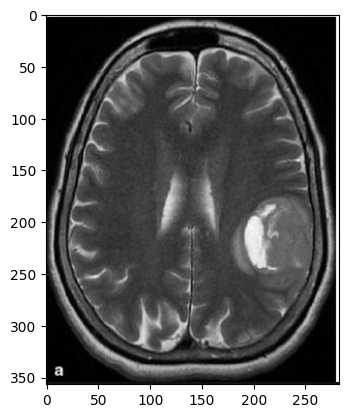

In [3]:
import cv2
import matplotlib.pyplot as plt
for i in cat:
    folders = os.path.join(path, i)
    for image in os.listdir(folders):
        image_path = os.path.join(folders, image)
        img = cv2.imread(image_path)
        plt.imshow(img)

In [4]:
import random

image_size = 200
input_image = []

for i in cat:
    folders = os.path.join(path, i)
    label = cat.index(i)
    for image in os.listdir(folders):
        image_path = os.path.join(folders, image)
        img = cv2.imread(image_path)
        img = cv2.resize(img, (image_size, image_size))
        input_image.append([img, label])

random.shuffle(input_image)

In [5]:
len(input_image)

253

In [6]:
253* .8

202.4

In [7]:
tr_size = int(0.8 * len(input_image))
te_size = len(input_image) - tr_size
input_image_tr = input_image[:tr_size]
input_image_te = input_image[tr_size:]
print(len(input_image_tr))
print(len(input_image_te))

202
51


In [13]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Prepare arrays
x_tr, y_tr = [], []
for x_val, labels in input_image_tr:
    x_tr.append(x_val)
    y_tr.append(labels)
x_tr = np.array(x_tr).astype("float32") / 255.0
y_tr = np.array(y_tr)

x_te, y_te = [], []
for x_val, labels in input_image_te:
    x_te.append(x_val)
    y_te.append(labels)
x_te = np.array(x_te).astype("float32") / 255.0
y_te = np.array(y_te)

# Model
model = Sequential()
model.add(Input(shape=x_tr.shape[1:]))
model.add(Conv2D(32, (3, 3), activation="relu"))
model.add(MaxPool2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPool2D((2, 2)))
model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.3))
model.add(Dense(1, activation="sigmoid"))

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Augmentation + Training
datagen = ImageDataGenerator(
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    datagen.flow(x_tr, y_tr, batch_size=32),
    epochs=50,
    validation_data=(x_te, y_te),
    callbacks=[early_stop]
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 736ms/step - accuracy: 0.5990 - loss: 0.8089 - val_accuracy: 0.7647 - val_loss: 0.5344
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 696ms/step - accuracy: 0.6832 - loss: 0.6187 - val_accuracy: 0.7647 - val_loss: 0.5567
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 748ms/step - accuracy: 0.7277 - loss: 0.5544 - val_accuracy: 0.8039 - val_loss: 0.5131
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 761ms/step - accuracy: 0.7277 - loss: 0.5819 - val_accuracy: 0.7843 - val_loss: 0.4955
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 686ms/step - accuracy: 0.6881 - loss: 0.5811 - val_accuracy: 0.7255 - val_loss: 0.5389
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 672ms/step - accuracy: 0.7228 - loss: 0.5523 - val_accuracy: 0.7647 - val_loss: 0.5214
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 724ms/step - accuracy: 0.6931 - loss: 0.5445 - val_accuracy: 0.7647 - val_loss: 0.5079
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 705ms/step - accuracy: 0.7376 - loss: 0.5494 - val_accuracy: 0.7059 - val_loss:

In [14]:
loss, acc = model.evaluate(x_te, y_te)
print(f"Test accuracy: {acc:.4f}")

loss, acc = model.evaluate(x_tr, y_tr)
print(f"Train accuracy: {acc:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.8235 - loss: 0.4875
Test accuracy: 0.8235
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.8119 - loss: 0.4580
Train accuracy: 0.8119


In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred_proba = model.predict(x_te)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

print("=== Classification Report ===")
print(classification_report(y_te, y_pred, labels=[0, 1], target_names=["No Tumor", "Tumor"]))

print("\n=== Confusion Matrix ===")
cm = confusion_matrix(y_te, y_pred)
print(cm)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
=== Classification Report ===
              precision    recall  f1-score   support

    No Tumor       0.81      0.68      0.74        19
       Tumor       0.83      0.91      0.87        32

    accuracy                           0.82        51
   macro avg       0.82      0.80      0.80        51
weighted avg       0.82      0.82      0.82        51


=== Confusion Matrix ===
[[13  6]
 [ 3 29]]


In [16]:
cm.diagonal().sum()/cm.sum()

np.float64(0.8235294117647058)

In [17]:
model.save("brain_tumor_model.h5")